<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/19_RegularizationL2L1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons

import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.optimizers import Adam

In [7]:
X, y = make_moons(100, noise=0.25,random_state=2)

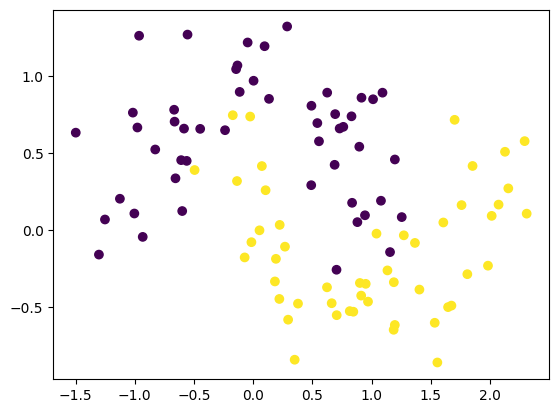

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [11]:
model1=Sequential()
model1.add(Dense(128, activation="relu", input_dim=2))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation="sigmoid"))

In [12]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
adam = Adam(learning_rate=0.01)

model1.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

In [16]:
history=model1.fit(X,y,epochs=1500, validation_split=0.2)

Epoch 1/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.6000 - loss: 0.6095 - val_accuracy: 0.9000 - val_loss: 0.3489
Epoch 2/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8500 - loss: 0.3987 - val_accuracy: 0.9000 - val_loss: 0.1981
Epoch 3/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8500 - loss: 0.4031 - val_accuracy: 0.9000 - val_loss: 0.1833
Epoch 4/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8500 - loss: 0.4102 - val_accuracy: 0.9000 - val_loss: 0.2163
Epoch 5/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8500 - loss: 0.3600 - val_accuracy: 0.9000 - val_loss: 0.2145
Epoch 6/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8500 - loss: 0.3442 - val_accuracy: 0.9000 - val_loss: 0.2402
Epoch 7/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8500 - loss: 0.3375 - val_accuracy: 0.9000 - val_loss: 0.2296
Epoch 8/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8375 - loss: 0.3257 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

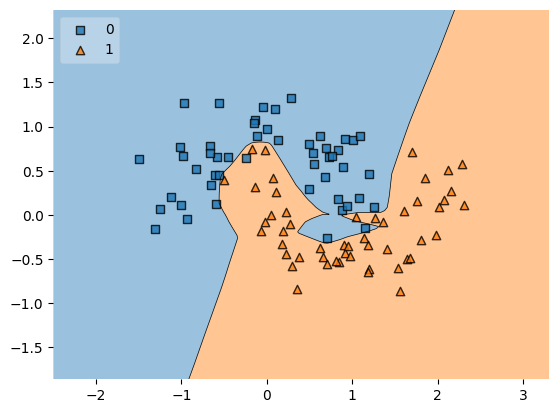

In [17]:
plot_decision_regions(X,y, clf=model1,legend=2)

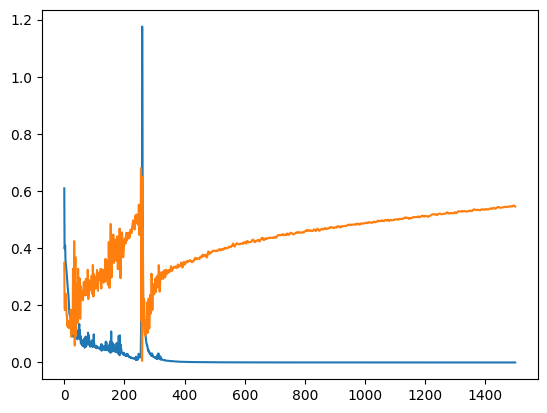

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

**L2-Regularization**

In [24]:
model2=Sequential()
model2.add(Dense(128, activation="relu", input_dim=2, kernel_regularizer=keras.regularizers.L2(0.001)))
model2.add(Dense(128, activation="relu", kernel_regularizer=keras.regularizers.L2(0.001)))
model2.add(Dense(1,activation="sigmoid"))

In [25]:
model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
adam = Adam(learning_rate=0.01)
model2.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

In [28]:
history1=model2.fit(X,y,epochs=1500, validation_split=0.2)

Epoch 1/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.5750 - loss: 0.7423 - val_accuracy: 0.8500 - val_loss: 0.5393
Epoch 2/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7750 - loss: 0.5535 - val_accuracy: 0.9000 - val_loss: 0.3577
Epoch 3/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8375 - loss: 0.4677 - val_accuracy: 0.8500 - val_loss: 0.2821
Epoch 4/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8250 - loss: 0.4757 - val_accuracy: 0.9000 - val_loss: 0.3171
Epoch 5/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8500 - loss: 0.4453 - val_accuracy: 0.9000 - val_loss: 0.3314
Epoch 6/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8500 - loss: 0.4311 - val_accuracy: 0.9000 - val_loss: 0.3240
Epoch 7/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8500 - loss: 0.4133 - val_accuracy: 0.9000 - val_loss: 0.3011
Epoch 8/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8500 - loss: 0.4073 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


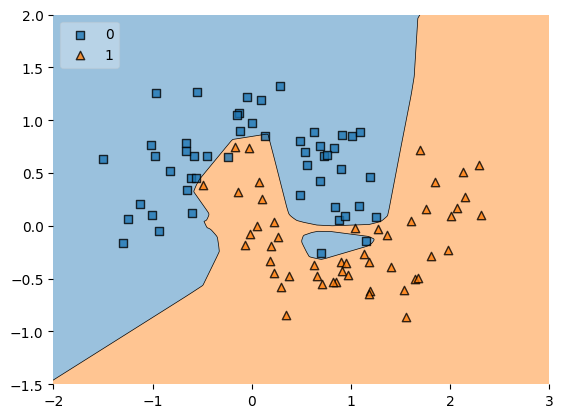

In [30]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

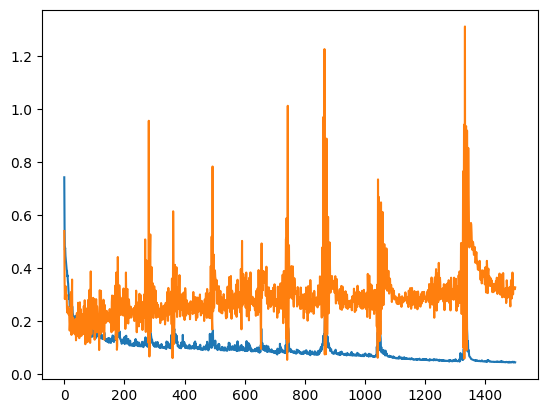

In [31]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [32]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

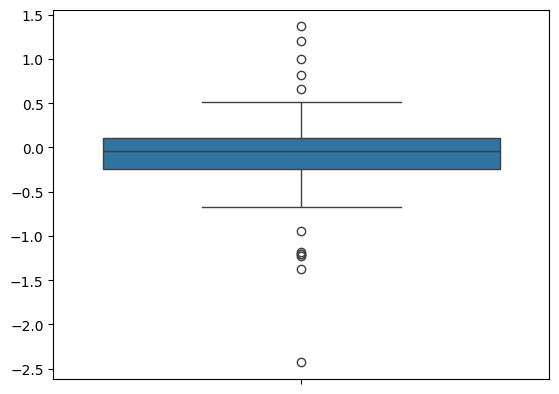

In [33]:
sns.boxplot(model1_weight_layer1)

<Axes: >

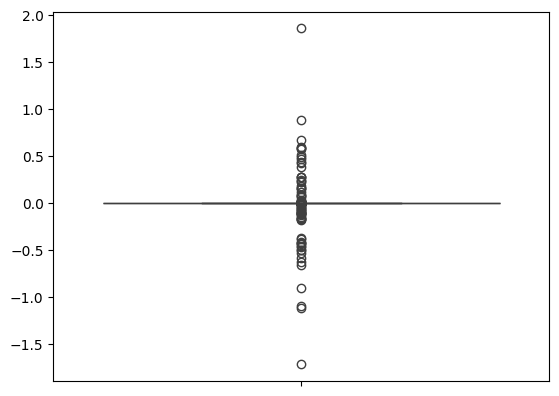

In [35]:
sns.boxplot(model2_weight_layer1)

In [36]:
model1_weight_layer1.min()

np.float32(-2.4297073)

In [37]:
model2_weight_layer1.min()

np.float32(-1.71763)

/tmp/ipykernel_793/2224180084.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipykernel_793/2224180084.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: ylabel='Density'>

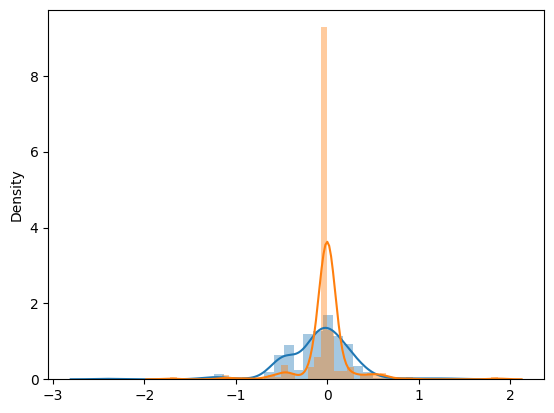

In [38]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

**L1**

In [39]:
model3 = Sequential()

model3.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model3.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model3.add(Dense(1,activation='sigmoid'))

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
adam = Adam(learning_rate=0.01)
model3.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

In [41]:
history2=model3.fit(X,y,epochs=10, validation_split=0.2)
#history1=model2.fit(X,y,epochs=1500, validation_split=0.2)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.7250 - loss: 1.8119 - val_accuracy: 0.9000 - val_loss: 1.4103
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8500 - loss: 1.3527 - val_accuracy: 0.9000 - val_loss: 0.9982
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8375 - loss: 1.0594 - val_accuracy: 0.9000 - val_loss: 0.7824
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8500 - loss: 0.8764 - val_accuracy: 0.9000 - val_loss: 0.6987
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8375 - loss: 0.7526 - val_accuracy: 0.9000 - val_loss: 0.6144
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8250 - loss: 0.7360 - val_accuracy: 0.8500 - val_loss: 0.5854
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8375 - loss: 0.6823 - val_accuracy: 0.9000 - val_loss: 0.5744
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8500 - loss: 0.6433 - val_accuracy: 0.9000 - val_loss: 0.5338

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


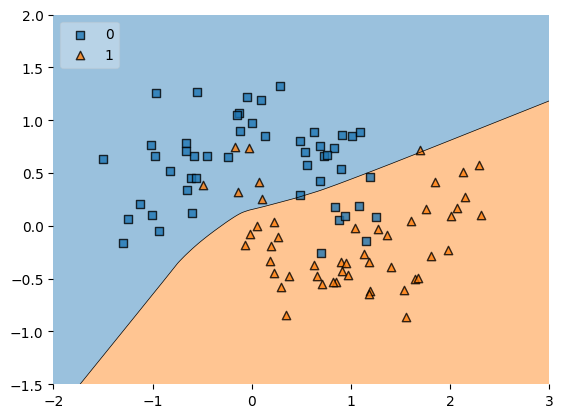

In [42]:
plot_decision_regions(X, y.astype('int'), clf=model3, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

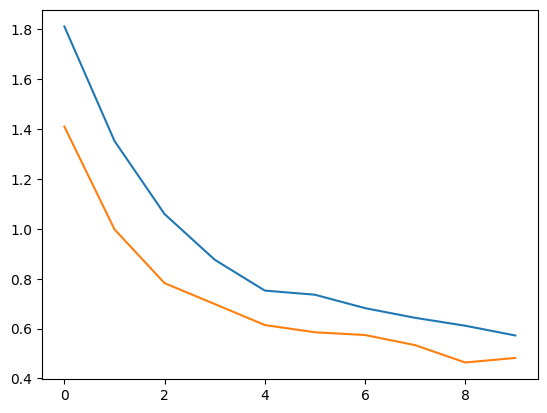

In [43]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [44]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model3_weight_layer1 = model3.get_weights()[0].reshape(256)

<Axes: >

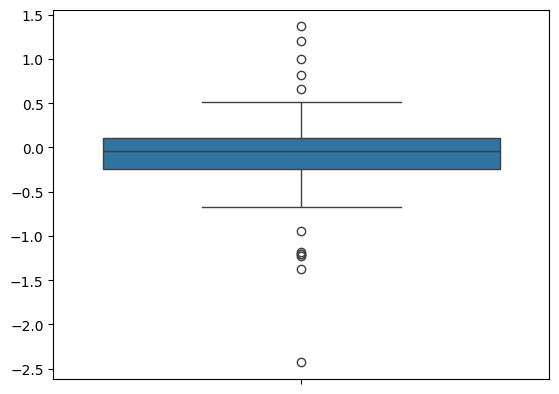

In [45]:
sns.boxplot(model1_weight_layer1)

<Axes: >

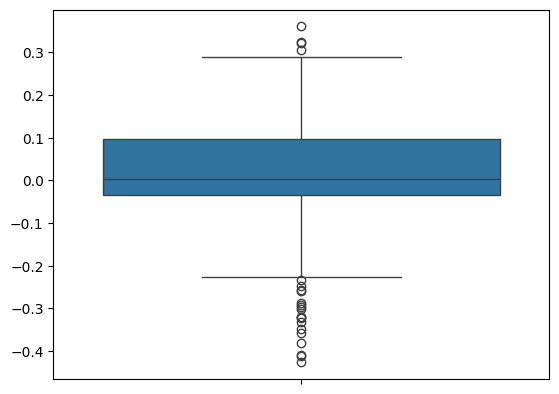

In [46]:
sns.boxplot(model3_weight_layer1)

/tmp/ipykernel_793/952455582.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipykernel_793/952455582.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: ylabel='Density'>

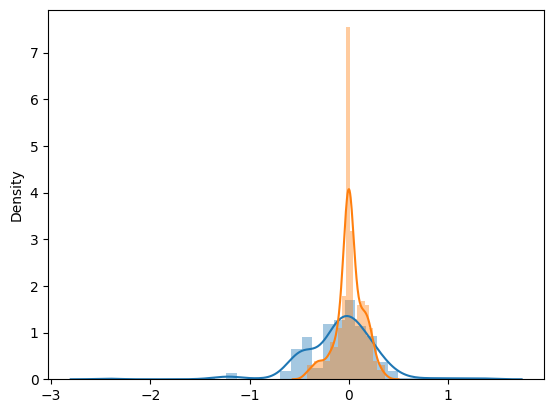

In [47]:
sns.distplot(model1_weight_layer1)
sns.distplot(model3_weight_layer1)